# Aula 13 — Laboratório POF: Microdados do Orçamento das Famílias
Semana 7 | 50 min | Referências: McKinney, Cap. 5 (pandas) · Cap. 6 (I/O de arquivos) · Cap. 9 (agregações e groupby)

**Dados reais do IBGE**: POF 2017-18 (Pesquisa de Orçamento Familiares), versão simplificada
em 3 arquivos CSV. Hoje é *lab*: menos teoria, mais código em cima de uma base grande.

## 🎯 Objetivos de aprendizagem
Ao final desta aula, você será capaz de:

- Ler três bases CSV de dezenas de milhares de linhas e inspecionar schema, contagens e qualidade;
- Combinar bases diferentes com `merge` 1:1 por uma chave (`household_id`), tratando duplicatas;
- Criar **faixas de renda** comparáveis em salários mínimos com `pd.cut`;
- Reproduzir a **Lei de Engel** com dados brasileiros: a participação da alimentação no gasto cai com a renda;
- Reconhecer a limitação de estatísticas **não-ponderadas** (sem fator de expansão amostral).

In [1]:
# Setup — imports e padrões visuais usados na aula
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

def brl(x):
    """Formata um número como moeda brasileira: R$ 1.234,56."""
    return f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

DATA = Path("../data/csv")  # notebook mora em semana_07/; dados em data/csv/

np.random.seed(42)  # reprodutibilidade quando houver aleatoriedade

## 1. Conhecendo as bases: onde, quem e quanto

A POF é o retrato mais completo do consumo das famílias brasileiras. Nesta versão didática,
cada **domicílio** aparece em três arquivos, todos com a mesma chave `household_id`:

| arquivo | o que descreve | colunas principais |
|---|---|---|
| `pof_domicilio.csv` | **onde** a família mora | `UF`, `SITUACAO` (1 = urbano, 2 = rural) |
| `pof_morador.csv` | quem responde (pessoa de referência) | `ANOS_EST`, `NIVEL_INST`, `RENDA_PC` (R$/mês per capita), `hh_size` |
| `pof_despesa_categoria.csv` | quanto gasta, por grupo | `food`, `housing`, `transport`, `health`, `other` (R$/ano, deflacionados) |

Antes de qualquer análise, o ritual do economista: **quantas linhas, quais colunas, que valores**.

In [2]:
# Leitura das três bases (CSVs locais — offline-first, sem internet)
dom = pd.read_csv(DATA / "pof_domicilio.csv")
mor = pd.read_csv(DATA / "pof_morador.csv")
dep = pd.read_csv(DATA / "pof_despesa_categoria.csv")

print(f"domicilio: {dom.shape[0]:,} linhas | morador: {mor.shape[0]:,} | despesa: {dep.shape[0]:,}")

domicilio: 57,920 linhas | morador: 58,039 | despesa: 57,799


In [3]:
# Onde as famílias moram: UF (código IBGE; Goiás = 52) e situação censitária
print(dom["UF"].value_counts().sort_index().head(8))
print(f"\nGoiás (UF 52): {len(dom[dom['UF'] == 52]):,} domicílios na amostra")
dom.head(3)

UF
11     951
12     950
13    1833
14     765
15    2130
16     762
17     923
21    2064
Name: count, dtype: int64

Goiás (UF 52): 2,232 domicílios na amostra


,household_id,UF,SITUACAO
0,110005400_1,11,1
1,110005400_2,11,1
2,110005400_4,11,1


In [4]:
# Perfil do respondente: anos de estudo, instrução (códigos 1-7) e renda per capita
mor[["ANOS_EST", "NIVEL_INST", "RENDA_PC", "hh_size"]].describe().round(1)

,ANOS_EST,NIVEL_INST,RENDA_PC,hh_size
count,58039.0,58039.0,58039.0,58039.0
mean,8.2,3.5,1687.0,3.1
std,4.9,1.9,2469.0,1.6
min,0.0,1.0,-1658.7,1.0
25%,5.0,2.0,671.0,2.0
50%,9.0,3.0,1154.6,3.0
75%,12.0,5.0,1895.5,4.0
max,16.0,7.0,237869.0,17.0


In [5]:
# Gasto anualizado por categoria (R$ deflacionados); montamos a despesa total da casa
dep["despesa_total"] = dep[["food", "housing", "transport", "health", "other"]].sum(axis=1)
dep.head(3)

,household_id,food,health,housing,other,transport,despesa_total
0,110000016_10,2967.28,0.0,0.00,1471.86,0.00,4439.14
1,110000016_12,5205.56,0.0,1495.02,6563.84,21.18,13285.60
2,110000016_13,4090.76,0.0,721.48,707.64,21.18,5541.06


## 2. O merge: juntando as três bases pela chave do domicílio

Cada base tem **uma linha por domicílio** (menos a de moradores, que tem 119 repetições —
a POF registra mais de um respondente em algumas casas). Decisão didática: ficamos com a
linha de **maior renda per capita** de cada casa, o respondente econômico principal.

O `merge` com `how="inner"` devolve apenas domicílios presentes **nas três** bases.

In [6]:
# 58.039 linhas → 57.920 domicílios únicos: deduplicamos mantendo a maior renda per capita
mor_unico = mor.sort_values("RENDA_PC").drop_duplicates("household_id", keep="last")
print(f"morador: {len(mor):,} linhas → {len(mor_unico):,} domicílios únicos")

morador: 58,039 linhas → 57,920 domicílios únicos


In [7]:
# Merge 1:1 em cadeia pela chave household_id (inner: precisa estar nas três bases)
pof = (dom
       .merge(mor_unico, on="household_id", how="inner")
       .merge(dep, on="household_id", how="inner"))

# Rendas per capita negativas (57 casos) são déficits de contas na POF: fora da análise
pof = pof[pof["RENDA_PC"] >= 0].copy()
print(f"base final: {len(pof):,} domicílios × {pof.shape[1]} colunas")
pof.head(3)

base final: 57,744 domicílios × 13 colunas


,household_id,UF,SITUACAO,ANOS_EST,NIVEL_INST,RENDA_PC,hh_size,food,health,housing,other,transport,despesa_total
0,110005400_1,11,1,16,7,2488.984375,4,7763.56,0.0,857.21,123.38,0.0,8744.15
1,110005400_2,11,1,12,5,3474.625556,3,2048.96,0.0,417.45,0.00,0.0,2466.41
2,110005400_4,11,1,6,2,1282.527685,3,2674.68,0.0,62.19,0.00,0.0,2736.87


## 3. Faixas de renda em salários mínimos com `pd.cut`

Comparar rendas em R$ brutos mistura realidades; comparar em **salários mínimos** dá escala
econômica. O SM de referência da POF 2017-18 é o de 2018: **R$ 954,00**. Como a renda da base
é **per capita**, dividimos a família inteira: um domicílio de 4 pessoas com R$ 3.816 de renda
total vive com **1 SM por pessoa**.

`pd.cut` recebe os cortes (`bins`) e os rótulos (`labels`); com `right=False`, o limite
inferior entra na faixa (`[0, 477)` → "até 1/2 SM").

In [8]:
# Faixas de renda per capita em múltiplos do SM de 2018 (R$ 954,00)
SM_2018 = 954.00
bins = [0, SM_2018 / 2, 2 * SM_2018, 5 * SM_2018, np.inf]
rotulos = ["até 1/2 SM", "1/2 a 2 SM", "2 a 5 SM", "acima de 5 SM"]

pof["faixa_renda"] = pd.cut(pof["RENDA_PC"], bins=bins, labels=rotulos, right=False)
pof["faixa_renda"].value_counts().sort_index()

faixa_renda
até 1/2 SM        8179
1/2 a 2 SM       35229
2 a 5 SM         11465
acima de 5 SM     2871
Name: count, dtype: int64

## 4. Lei de Engel: quanto mais pobre, maior a fatia da alimentação

Em 1857, o estatístico **Ernst Engel** observou o que hoje é um dos fatos mais robustos da
economia: **a participação da alimentação no gasto total cai conforme a renda sobe**.
A intuição vem antes da conta: comer é necessidade básica — uma família pobre gasta quase
tudo com comida; quando a renda dobra, ela come melhor, mas **não come o dobro**. A renda
extra vai para moradia, transporte, educação, lazer.

Esse padrão fundou a teoria das **elasticidades-renda de demanda** e até hoje orienta
cestas de inflação (o peso da alimentação no IPCA cai conforme o país enriquece).

In [9]:
# Gasto médio e participação da alimentação por faixa de renda (Lei de Engel)
por_faixa = pof.groupby("faixa_renda", observed=True)[["food", "despesa_total"]].mean()
por_faixa["part_food"] = por_faixa["food"] / por_faixa["despesa_total"]
por_faixa.round(2)

,food,despesa_total,part_food
faixa_renda,,,
até 1/2 SM,1908.61,3344.96,0.57
1/2 a 2 SM,2882.83,5335.92,0.54
2 a 5 SM,4192.65,9260.09,0.45
acima de 5 SM,6360.52,19967.69,0.32


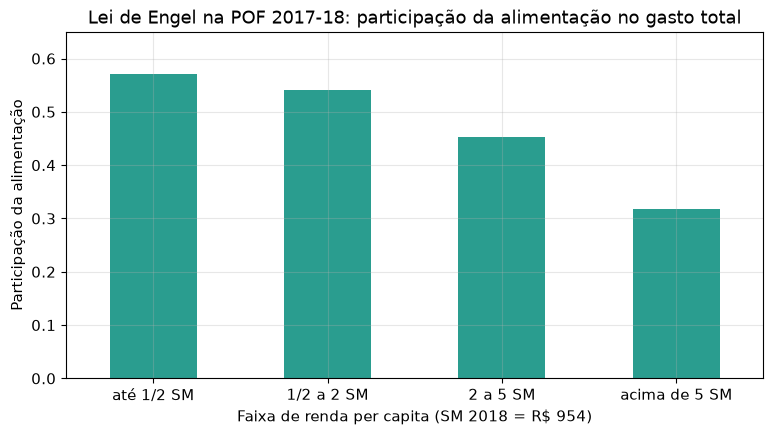

In [10]:
# Gráfico 1 — a participação CAE conforme a renda sobe: a Lei de Engel em dados brasileiros
fig, ax = plt.subplots()
por_faixa["part_food"].plot.bar(ax=ax, color="#2a9d8f")
ax.set_title("Lei de Engel na POF 2017-18: participação da alimentação no gasto total")
ax.set_xlabel("Faixa de renda per capita (SM 2018 = R$ 954)")
ax.set_ylabel("Participação da alimentação")
ax.set_ylim(0, 0.65)
plt.xticks(rotation=0)
plt.show()

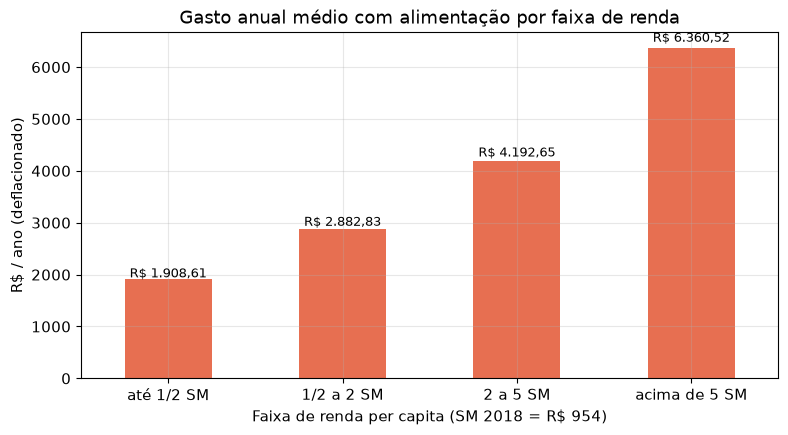

In [11]:
# Gráfico 2 — em R$ o gasto com comida SOBE; Engel é sobre participação, não valor absoluto
fig, ax = plt.subplots()
por_faixa["food"].plot.bar(ax=ax, color="#e76f51")
ax.set_title("Gasto anual médio com alimentação por faixa de renda")
ax.set_xlabel("Faixa de renda per capita (SM 2018 = R$ 954)")
ax.set_ylabel("R$ / ano (deflacionado)")
for i, v in enumerate(por_faixa["food"]):
    ax.text(i, v * 1.02, brl(v), ha="center", fontsize=9)
plt.xticks(rotation=0)
plt.show()

## 5. Goiás em foco (UF = 52)

Todo lab deste curso tem recorte regional: são **2.232 domicílios goianos** na POF 2017-18
(código IBGE 52; o DF vizinho é 53). Pergunta de economista: o padrão de Engel que vimos no
Brasil se repete no Cerrado granoleiro?

In [12]:
# Recorte de Goiás: quantos domicílios e como se distribuem urbano × rural
go = pof[pof["UF"] == 52].copy()
print(f"Goiás: {len(go):,} domicílios ({len(go) / len(pof):.1%} da amostra)")
print(go["SITUACAO"].value_counts().rename({1: "urbano", 2: "rural"}))

Goiás: 2,223 domicílios (3.8% da amostra)
SITUACAO
urbano    1222
rural     1001
Name: count, dtype: int64


In [13]:
# A tabela de Engel de Goiás — mesmo formato da seção 4, outro filtro
go_faixa = go.groupby("faixa_renda", observed=True)[["food", "despesa_total"]].mean()
go_faixa["part_food"] = go_faixa["food"] / go_faixa["despesa_total"]
go_faixa.round(2)

,food,despesa_total,part_food
faixa_renda,,,
até 1/2 SM,2343.71,5069.14,0.46
1/2 a 2 SM,2827.44,5500.23,0.51
2 a 5 SM,3564.55,8682.79,0.41
acima de 5 SM,7129.33,19115.09,0.37


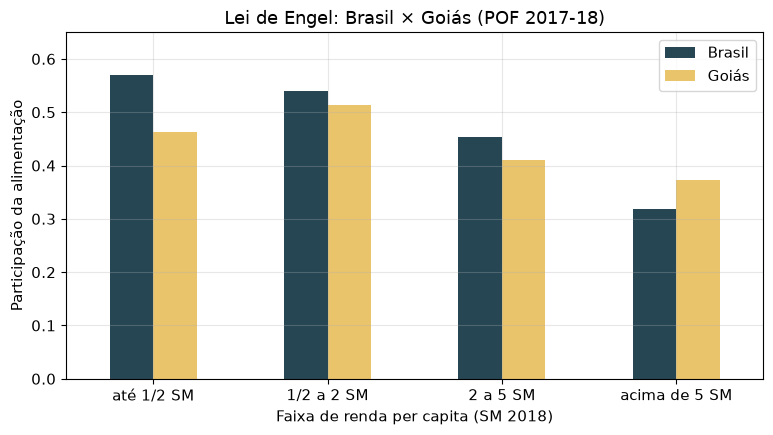

In [14]:
# Gráfico 3 — Brasil × Goiás lado a lado: a lei vale também no Cerrado?
compara = pd.DataFrame({"Brasil": por_faixa["part_food"], "Goiás": go_faixa["part_food"]})
fig, ax = plt.subplots()
compara.plot.bar(ax=ax, color=["#264653", "#e9c46a"])
ax.set_title("Lei de Engel: Brasil × Goiás (POF 2017-18)")
ax.set_xlabel("Faixa de renda per capita (SM 2018)")
ax.set_ylabel("Participação da alimentação")
ax.set_ylim(0, 0.65)
plt.xticks(rotation=0)
plt.show()

## 6. Urbano × rural

77% dos domicílios da amostra são urbanos. A expectativa econômica: no rural a participação
da alimentação tende a ser **menor** — há produção para consumo próprio (o gasto de mercado
é menor) e a renda monetária per capita costuma ser mais baixa, o que puxa o efeito em direções
opostas. Os dados decidem.

In [15]:
# Urbano (1) × rural (2): gasto médio, renda e participação da alimentação
sit = pof.groupby("SITUACAO")[["food", "despesa_total", "RENDA_PC"]].mean()
sit["part_food"] = sit["food"] / sit["despesa_total"]
sit.index = sit.index.map({1: "urbano", 2: "rural"})
sit.round(2)

,food,despesa_total,RENDA_PC,part_food
SITUACAO,,,,
urbano,3543.50,7096.77,1819.17,0.50
rural,1926.86,4726.19,1256.90,0.41


## 7. Escolaridade e renda: o prêmio da educação

`NIVEL_INST` usa os códigos do quesito de instrução da POF: de **1** (sem instrução) a
**7** (superior completo). A hipótese de capital humano: mais anos de estudo → maior
produtividade → maior renda. Vamos testar com médias por nível.

In [16]:
# Renda e escolaridade média por nível de instrução (códigos 1-7 da POF)
NIVEL_LABEL = {1: "sem instrução", 2: "fund. incompleto", 3: "fund. completo",
               4: "médio incompleto", 5: "médio completo",
               6: "superior incompleto", 7: "superior completo"}

escol = pof.groupby("NIVEL_INST").agg(
    anos_estudo=("ANOS_EST", "mean"),
    renda_pc_media=("RENDA_PC", "mean"),
    n_respondentes=("RENDA_PC", "count"),
)
escol.index = escol.index.map(NIVEL_LABEL)
escol.round(0)

,anos_estudo,renda_pc_media,n_respondentes
NIVEL_INST,,,
sem instrução,0.0,1077.0,5306
fund. incompleto,5.0,1221.0,23035
fund. completo,9.0,1427.0,4803
médio incompleto,11.0,1254.0,2910
médio completo,12.0,1662.0,13113
superior incompleto,14.0,2331.0,1788
superior completo,16.0,4033.0,6789


## 📝 Exercícios

Resolva no espaço indicado e só depois compare com a solução. Todos usam a base `pof`
já construída e `SM_2018` definido acima.

**EXERCÍCIO 1 — E a moradia?** Repita a análise de Engel para a categoria `housing`
(moradia): calcule a participação média de `housing` no gasto total por faixa de renda.
A participação também cai com a renda, sobe, ou fica estável? Discuta por quê (dica: moradia
tem componente fixo — aluguel/condomínio — e componente de luxo).

In [17]:
# EXERCÍCIO 1 — seu código aqui


In [18]:
# SOLUÇÃO 1 — mesma receita da seção 4, trocando food por housing
por_faixa_h = pof.groupby("faixa_renda", observed=True)[["housing", "despesa_total"]].mean()
por_faixa_h["part_housing"] = por_faixa_h["housing"] / por_faixa_h["despesa_total"]
por_faixa_h.round(2)
# Leitura: ao contrário da alimentação, a participação da moradia SOBE no topo da
# distribuição (0,11 → 0,15): moradia combina gasto fixo com serviços que a renda
# alta consome mais — aluguel melhor, condomínio, manutenção.

,housing,despesa_total,part_housing
faixa_renda,,,
até 1/2 SM,374.30,3344.96,0.11
1/2 a 2 SM,552.03,5335.92,0.10
2 a 5 SM,1067.33,9260.09,0.12
acima de 5 SM,2980.25,19967.69,0.15


**EXERCÍCIO 2 — Renda urbano × rural em Goiás.** Em Goiás, quanto ganha em média (per
capita) quem mora na cidade vs quem mora no campo? A diferença é grande? Interprete à luz do
agronegócio goiano (alta produtividade rural × renda monetária urbana).

In [19]:
# EXERCÍCIO 2 — seu código aqui


In [20]:
# SOLUÇÃO 2 — filtro de Goiás + groupby por situação censitária
renda_go = go.groupby("SITUACAO")["RENDA_PC"].mean().rename({1: "urbano", 2: "rural"})
renda_go.round(0).apply(brl)  # renda per capita mensal média

SITUACAO
urbano    R$ 1.758,00
rural     R$ 1.640,00
Name: RENDA_PC, dtype: str

**EXERCÍCIO 3 — Onde está a classe média alta?** Para cada UF, calcule o **percentual de
domicílios com renda per capita acima de 5 SM** e mostre o top 5. Use o dicionário de siglas
abaixo para rotular. (Goiás aparece no ranking? Como se explica?)

In [21]:
# EXERCÍCIO 3 — seu código aqui


In [22]:
# SOLUÇÃO 3 — indicador booleano por linha + média por grupo = proporção
UF_SIGLA = {11: "RO", 12: "AC", 13: "AM", 14: "RR", 15: "PA", 16: "AP", 17: "TO",
            21: "MA", 22: "PI", 23: "CE", 24: "RN", 25: "PB", 26: "PE", 27: "AL",
            28: "SE", 29: "BA", 31: "MG", 32: "ES", 33: "RJ", 35: "SP", 41: "PR",
            42: "SC", 43: "RS", 50: "MS", 51: "MT", 52: "GO", 53: "DF"}

acima_5sm = (pof["RENDA_PC"] > 5 * SM_2018)          # Series booleana: True = acima de 5 SM
top_uf = (pof.assign(acima_5sm=acima_5sm)
             .groupby("UF")["acima_5sm"].mean()       # média de True/False = proporção
             .sort_values(ascending=False)
             .head(5))
top_uf.rename(index=UF_SIGLA).round(3)

UF
DF    0.194
SP    0.099
RS    0.085
RJ    0.080
SC    0.069
Name: acima_5sm, dtype: float64

**EXERCÍCIO 4 — O prêmio salarial da escolaridade, em número.** Calcule a **correlação
de Pearson** entre `ANOS_EST` (anos de estudo) e `RENDA_PC` na base completa. É forte,
fraca? O que a correlação NÃO diz (dica: causalidade e variáveis omitidas)?

In [23]:
# EXERCÍCIO 4 — seu código aqui


In [24]:
# SOLUÇÃO 4 — matriz de correlação par a par (Pearson)
corr = pof[["ANOS_EST", "RENDA_PC"]].corr().round(3)
corr
# Correlação positiva de intensidade moderada: mais estudo, em média, mais renda.
# MAS correlação ≠ causalidade: família de origem, região, idade e setor confundem a relação.

,ANOS_EST,RENDA_PC
ANOS_EST,1.000,0.271
RENDA_PC,0.271,1.000


## 📌 Resumo & para casa

- **Pipeline clássico de microdados**: ler → inspecionar → deduplicar → `merge` pela chave →
  variável derivada (`faixa_renda` via `pd.cut`) → `groupby` → gráfico. É o mesmo esqueleto
  de qualquer análise de PNAD, POF, Censo ou RAIS.
- **Lei de Engel confirmada nos dados**: a participação da alimentação cai de ~57% (até ½ SM)
  para ~32% (acima de 5 SM) — elasticidade-renda da demanda por alimentos menor que 1.
- Goiás segue o padrão nacional, com recortes próprios de um estado do agronegócio.
- `groupby(...).agg(...)` com `named aggregation` deixa o código legível para qualquer pessoa.
- **Limitação honesta**: esta versão da POF **não tem pesos amostrais** (fator de expansão).
  Todas as estatísticas são **não-ponderadas**: descrevem a *amostra*, não a população
  brasileira. Em pesquisa de verdade, use `survey` (R) ou os pesos originais do IBGE.

**Para casa**: com a mesma base, escolha uma UF de interesse e escreva 5 linhas de análise
(uma tabela + um gráfico) para apresentar na próxima aula.

**Referências (KB)**:
- `kb/01_mckinney_python_for_data_analysis/07_chapter-5-getting-started-with-pandas.md` — Series, DataFrame, indexação
- `kb/01_mckinney_python_for_data_analysis/08_chapter-6-data-loading-storage-and-file-formats.md` — `read_csv`, I/O
- `kb/01_mckinney_python_for_data_analysis/11_chapter-9-data-aggregation-and-group-operations.md` — `groupby`, `agg`, `cut`